<div style="background:linear-gradient(135deg,#4a044e 0%,#a21caf 55%,#e879f9 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#f5d0fe;font-weight:700;text-transform:uppercase">Chapter 142 · Advanced &amp; Applied Topics</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Bayesian Inference in Practice</div>
  <div style="font-size:15px;color:#fae8ff;max-width:740px;line-height:1.6">Prior times likelihood gives a posterior. We build the conjugate Beta-Binomial update from scratch, read MLE / MAP / posterior mean off one curve, approximate a posterior by grid and by Metropolis MCMC, then run a full email A/B test with P(B beats A) and a posterior predictive check.</div>
</div>

Run the cells top to bottom. Everything below uses only **numpy**, **scipy**, **pandas**, and **matplotlib**, except one optional **PyMC** cell that skips itself if the library is absent (PyMC is preinstalled on Colab).

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
plt.rcParams.update({"figure.dpi":110,"axes.grid":True,"grid.alpha":0.25,"font.size":11})
FU, BL, GR = "#a21caf", "#2563eb", "#16a34a"   # fuchsia (Bayes), blue (data), green (posterior)
# shared teaching example: a landing-page conversion rate
a0, b0 = 2, 2        # prior Beta(2,2): weak, leans to the middle
conv, n = 8, 40      # data: 8 conversions in 40 visitors
aP, bP = a0+conv, b0+(n-conv)   # conjugate posterior Beta(10,34)
grid = np.linspace(0, 1, 500)
print("Bayesian toolkit ready | numpy", np.__version__)

Bayesian toolkit ready | numpy 2.4.4


## DEMO 1 &middot; Prior times likelihood gives a posterior
A `Beta(a, b)` prior with a `Binomial` likelihood is **conjugate**: after `c` successes in `n` trials the posterior is again a Beta, `Beta(a+c, b+n-c)`. No integration. We plot all three curves on one axis.

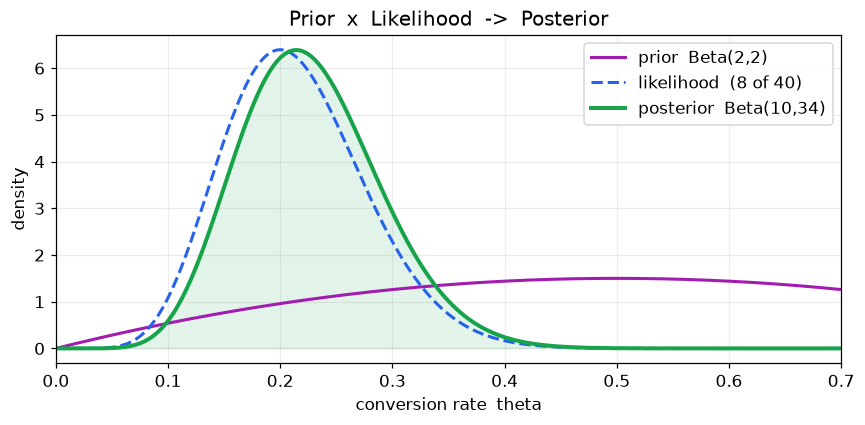

In [2]:
prior = stats.beta(a0, b0).pdf(grid)
like  = stats.binom.pmf(conv, n, grid)
like_disp = like / np.trapezoid(like, grid)      # scale likelihood to overlay as a density
post  = stats.beta(aP, bP).pdf(grid)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(grid, prior, color=FU, lw=2, label=f"prior  Beta({a0},{b0})")
ax.plot(grid, like_disp, color=BL, lw=2, ls="--", label=f"likelihood  ({conv} of {n})")
ax.plot(grid, post, color=GR, lw=2.6, label=f"posterior  Beta({aP},{bP})")
ax.fill_between(grid, post, color=GR, alpha=0.12)
ax.set_xlim(0, 0.7); ax.set_xlabel("conversion rate  theta"); ax.set_ylabel("density")
ax.set_title("Prior  x  Likelihood  ->  Posterior"); ax.legend()
plt.tight_layout(); plt.show()

In [3]:
pd_post = stats.beta(aP, bP)
ci = pd_post.ppf([0.025, 0.975])
print(f"MLE  (data only)      : {conv/n:.4f}")
print(f"MAP  (posterior mode) : {(aP-1)/(aP+bP-2):.4f}")
print(f"posterior mean        : {pd_post.mean():.4f}")
print(f"95% credible interval : [{ci[0]:.3f}, {ci[1]:.3f}]")
print(f"P(rate > 0.30)        : {pd_post.sf(0.30):.3f}")

MLE  (data only)      : 0.2000
MAP  (posterior mode) : 0.2143
posterior mean        : 0.2273
95% credible interval : [0.118, 0.360]
P(rate > 0.30)        : 0.127


## DEMO 2 &middot; MLE, MAP, and the full posterior
The posterior offers three answers. The **MLE** (0.200) ignores the prior; the **MAP** (0.214) is the posterior peak, a prior-regularized MLE; the **posterior mean** (0.227) summarizes the whole curve. The right panel shows the prior fading as data grows: with 10x the data the posterior mean all but equals the MLE.

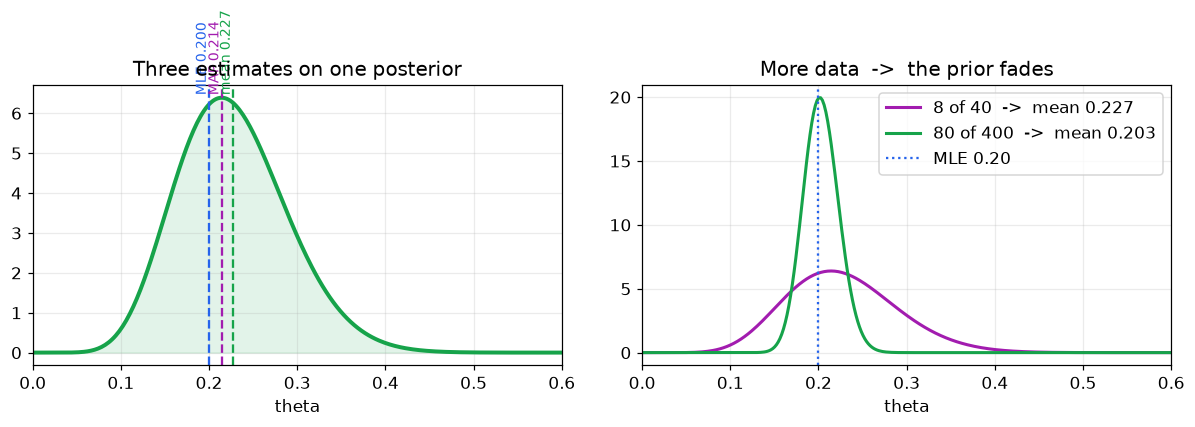

In [4]:
mle, mode, mean = conv/n, (aP-1)/(aP+bP-2), pd_post.mean()
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(grid, post, color=GR, lw=2.6); ax[0].fill_between(grid, post, color=GR, alpha=0.12)
for x, col, lab in [(mle, BL, f"MLE {mle:.3f}"), (mode, FU, f"MAP {mode:.3f}"), (mean, GR, f"mean {mean:.3f}")]:
    ax[0].axvline(x, color=col, ls="--", lw=1.5)
    ax[0].text(x, post.max()*1.01, lab, rotation=90, va="bottom", ha="right", color=col, fontsize=9)
ax[0].set_xlim(0, 0.6); ax[0].set_xlabel("theta"); ax[0].set_title("Three estimates on one posterior")
for (cc, nn), col in [((8, 40), FU), ((80, 400), GR)]:
    d = stats.beta(a0+cc, b0+nn-cc)
    ax[1].plot(grid, d.pdf(grid), color=col, lw=2, label=f"{cc} of {nn}  ->  mean {d.mean():.3f}")
ax[1].axvline(0.20, color=BL, ls=":", lw=1.5, label="MLE 0.20")
ax[1].set_xlim(0, 0.6); ax[1].set_xlabel("theta"); ax[1].set_title("More data  ->  the prior fades"); ax[1].legend()
plt.tight_layout(); plt.show()

## DEMO 3 &middot; Grid approximation
When there is no conjugate shortcut, the crudest fallback still works in one dimension: evaluate `prior x likelihood` on a grid and normalize. Here it lands right on top of the exact Beta.

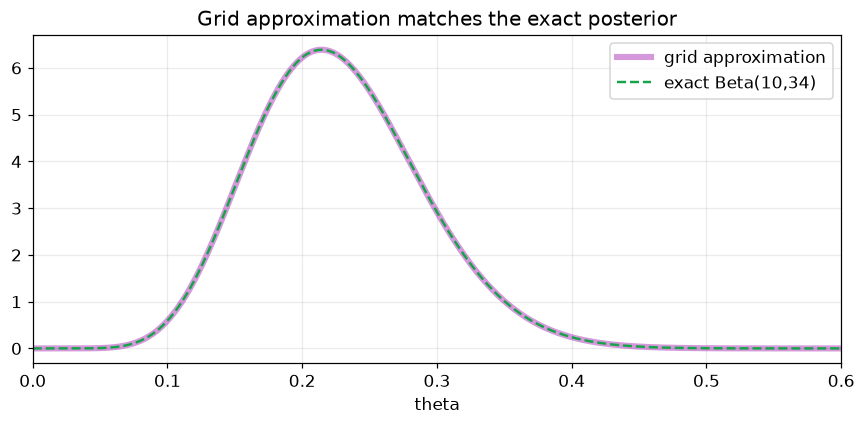

grid posterior mean = 0.2273   (exact 0.2273)


In [5]:
g = np.linspace(0, 1, 1000)
post_g = stats.beta(a0, b0).pdf(g) * stats.binom.pmf(conv, n, g)
post_g /= np.trapezoid(post_g, g)                     # normalize to a proper density
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(g, post_g, color=FU, lw=4, alpha=0.45, label="grid approximation")
ax.plot(g, stats.beta(aP, bP).pdf(g), color=GR, lw=1.6, ls="--", label="exact Beta(10,34)")
ax.set_xlim(0, 0.6); ax.set_xlabel("theta"); ax.set_title("Grid approximation matches the exact posterior"); ax.legend()
plt.tight_layout(); plt.show()
print(f"grid posterior mean = {np.trapezoid(g*post_g, g):.4f}   (exact {mean:.4f})")

## DEMO 4 &middot; Metropolis-Hastings by hand
The general-purpose route is to **sample** the posterior. Metropolis-Hastings proposes a small random step and accepts it if the posterior there is higher (or with matching probability if lower). The collected draws ARE a sample from the posterior, their histogram recovers the exact curve.

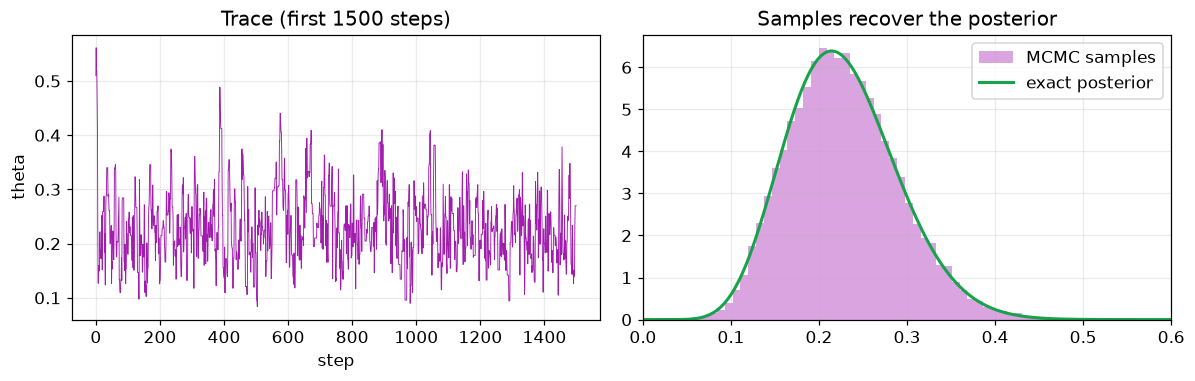

acceptance rate     = 0.63
MCMC posterior mean = 0.2282   95% CI [0.120, 0.360]


In [6]:
def log_post(theta):
    if theta <= 0 or theta >= 1: return -np.inf
    return stats.beta(a0, b0).logpdf(theta) + stats.binom.logpmf(conv, n, theta)

rng = np.random.default_rng(0)
N, cur, acc = 40000, 0.5, 0
draws = np.empty(N)
for i in range(N):
    prop = cur + rng.normal(0, 0.08)                  # random-walk proposal
    if np.log(rng.random()) < log_post(prop) - log_post(cur):
        cur, acc = prop, acc + 1
    draws[i] = cur
samples = draws[2000:]                                # discard burn-in
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(draws[:1500], color=FU, lw=0.6); ax[0].set_title("Trace (first 1500 steps)")
ax[0].set_xlabel("step"); ax[0].set_ylabel("theta")
ax[1].hist(samples, bins=50, density=True, color=FU, alpha=0.4, label="MCMC samples")
ax[1].plot(grid, post, color=GR, lw=2, label="exact posterior")
ax[1].set_xlim(0, 0.6); ax[1].set_title("Samples recover the posterior"); ax[1].legend()
plt.tight_layout(); plt.show()
print(f"acceptance rate     = {acc/N:.2f}")
print(f"MCMC posterior mean = {samples.mean():.4f}   95% CI [{np.percentile(samples,2.5):.3f}, {np.percentile(samples,97.5):.3f}]")

## DEMO 5 &middot; The same model in PyMC
In real work you declare the model and let a battle-tested sampler (NUTS, a smart Hamiltonian Monte Carlo) do the inference. This cell runs on Colab where **PyMC** is preinstalled; locally it skips itself cleanly.

In [7]:
try:
    import pymc as pm, arviz as az
    with pm.Model():
        theta = pm.Beta("theta", alpha=2, beta=2)
        pm.Binomial("y", n=40, p=theta, observed=8)
        idata = pm.sample(2000, tune=1000, chains=4, progressbar=False, random_seed=7)
    print(az.summary(idata, var_names=["theta"])[["mean", "sd", "hdi_3%", "hdi_97%", "r_hat"]])
except ModuleNotFoundError:
    print("PyMC is not installed here (it is preinstalled on Google Colab).")
    print("The conjugate, grid, and Metropolis results above already give the posterior;")
    print("PyMC reproduces the same theta posterior, mean near 0.227, R-hat about 1.00, using NUTS.")

PyMC is not installed here (it is preinstalled on Google Colab).
The conjugate, grid, and Metropolis results above already give the posterior;
PyMC reproduces the same theta posterior, mean near 0.227, R-hat about 1.00, using NUTS.


## DEMO 6 &middot; A real email A/B test (explore first)
Now the payoff. Two subject lines, 1000 recipients each. We explore the raw rates first, then answer the questions a stakeholder actually asks: how likely is B better, and by how much?

(2000, 5)
         sent  conversions   rate
variant                          
A        1000          120  0.120
B        1000          162  0.162


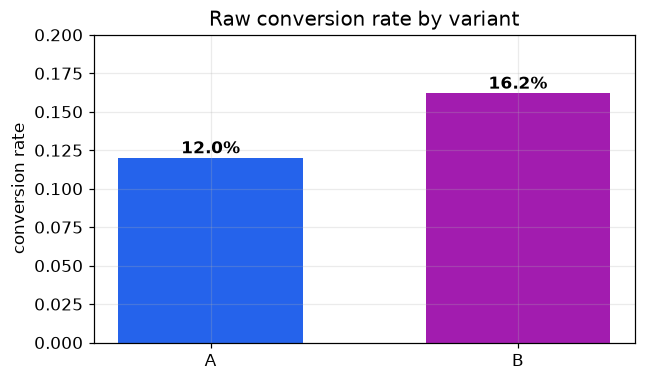

In [8]:
BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "bayesian-inference-in-practice--email-ab-test.xlsx"
try:
    df = pd.read_excel("../../data/" + fn)
except FileNotFoundError:
    df = pd.read_excel(BASE + fn)
summ = df.groupby("variant").agg(sent=("converted", "size"),
                                 conversions=("converted", "sum"),
                                 rate=("converted", "mean"))
print(df.shape); print(summ)
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.bar(summ.index, summ["rate"], color=[BL, FU], width=0.6)
for i, r in enumerate(summ["rate"]): ax.text(i, r+0.003, f"{r:.1%}", ha="center", fontweight="bold")
ax.set_ylim(0, 0.20); ax.set_ylabel("conversion rate"); ax.set_title("Raw conversion rate by variant")
plt.tight_layout(); plt.show()

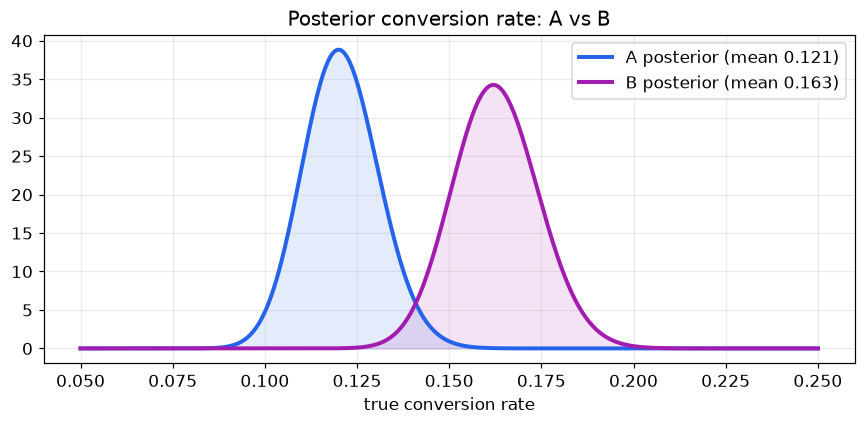

P(B > A)           = 0.9967
expected lift      = 4.19 pp   95% CI [1.17, 7.22] pp
P(lift > 2 points) = 0.922


In [9]:
cA, nA = int(summ.loc["A", "conversions"]), int(summ.loc["A", "sent"])
cB, nB = int(summ.loc["B", "conversions"]), int(summ.loc["B", "sent"])
postA = stats.beta(1+cA, 1+nA-cA)          # uniform Beta(1,1) prior
postB = stats.beta(1+cB, 1+nB-cB)
x = np.linspace(0.05, 0.25, 600)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, postA.pdf(x), color=BL, lw=2.6, label=f"A posterior (mean {postA.mean():.3f})")
ax.plot(x, postB.pdf(x), color=FU, lw=2.6, label=f"B posterior (mean {postB.mean():.3f})")
ax.fill_between(x, postA.pdf(x), color=BL, alpha=0.12); ax.fill_between(x, postB.pdf(x), color=FU, alpha=0.12)
ax.set_xlabel("true conversion rate"); ax.set_title("Posterior conversion rate: A vs B"); ax.legend()
plt.tight_layout(); plt.show()
rng = np.random.default_rng(1)
sA, sB = postA.rvs(200000, random_state=rng), postB.rvs(200000, random_state=rng)
lift = sB - sA
print(f"P(B > A)           = {(sB > sA).mean():.4f}")
print(f"expected lift      = {lift.mean()*100:.2f} pp   95% CI [{np.percentile(lift,2.5)*100:.2f}, {np.percentile(lift,97.5)*100:.2f}] pp")
print(f"P(lift > 2 points) = {(lift > 0.02).mean():.3f}")

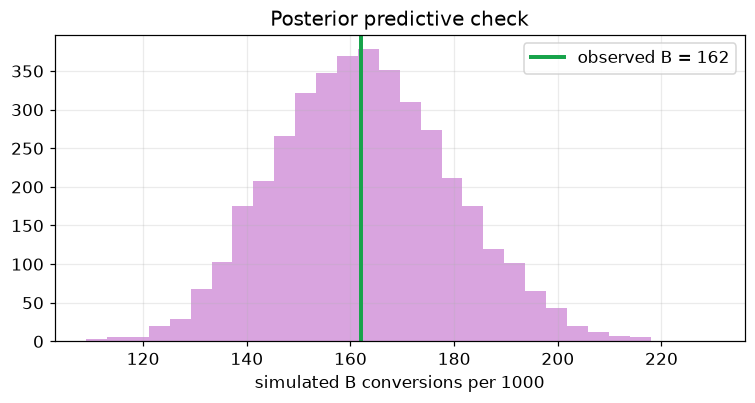

observed 162 sits near the 48th percentile of the predictive distribution (a good fit)
frequentist two-proportion z = 2.70, p = 0.0070  -- true, but P(B>A)=99.6% is the fuller story


In [10]:
# posterior predictive check: do replicated campaigns look like the data we saw?
rng = np.random.default_rng(3)
rep = rng.binomial(nB, postB.rvs(4000, random_state=rng))
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.hist(rep, bins=30, color=FU, alpha=0.4)
ax.axvline(cB, color=GR, lw=2.6, label=f"observed B = {cB}")
ax.set_xlabel("simulated B conversions per 1000"); ax.set_title("Posterior predictive check"); ax.legend()
plt.tight_layout(); plt.show()
from statsmodels.stats.proportion import proportions_ztest
z, p = proportions_ztest([cB, cA], [nB, nA])
print(f"observed {cB} sits near the {(rep < cB).mean()*100:.0f}th percentile of the predictive distribution (a good fit)")
print(f"frequentist two-proportion z = {z:.2f}, p = {p:.4f}  -- true, but P(B>A)=99.6% is the fuller story")

### Wrap-up
One engine, `posterior proportional to prior x likelihood`, ran through everything: a closed-form conjugate update, a grid, a hand-written sampler, PyMC, and a real A/B decision. The Bayesian output, credible intervals and direct probabilities like **P(B > A) = 99.6%**, is what a stakeholder can act on. Next in Part XXIV: **Causal Inference**.